In [1]:
pip install pandas numpy matplotlib seaborn scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
!python.exe -m pip install --upgrade pip

  Obtaining dependency information for pip from https://files.pythonhosted.org/packages/5d/95/6b5cb3461ea5673ba0995989746db58eb18b91b54dbf331e72f569540946/pip-26.1.2-py3-none-any.whl.metadata
   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   - -------------------------------------- 0.1/1.8 MB 272.3 kB/s eta 0:00:07
   - -------------------------------------- 0.1/1.8 MB 272.3 kB/s eta 0:00:07
   - -------------------------------------- 0.1/1.8 MB 272.3 kB/s eta 0:00:07
   -- ------------------------------------- 0.1/1.8 MB 218.5 kB/s eta 0:00:08
   -- ------------------------------------- 0.1/1.8 MB 218.5 kB/s eta 0:00:08
   -- ------------------------------------- 0.1/1.8 MB 242.7 kB/s eta 0:00:08
   -- ------------------------------------- 0.1/1.8 MB 225.3 kB/

In [9]:
#  Load the manually downloaded Kaggle dataset
import pandas as pd

# Load the specific file downloaded from your Kaggle link
filename = 'heart_disease_uci.csv'

try:
    df = pd.read_csv(filename)
    print(f" Successfully loaded {filename}")
    print(f"Dataset shape: {df.shape}")
    print("\nColumns in this dataset:")
    print(df.columns.tolist())
    print("\nFirst 5 rows:")
    print(df.head())
except FileNotFoundError:
    print(f" Error: Could not find '{filename}' in the current folder.")
    print("Please make sure you downloaded and extracted the file, and placed it in the correct folder.")

 Successfully loaded heart_disease_uci.csv
Dataset shape: (920, 16)

Columns in this dataset:
['id', 'age', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num']

First 5 rows:
   id  age     sex    dataset               cp  trestbps   chol    fbs  \
0   1   63    Male  Cleveland   typical angina     145.0  233.0   True   
1   2   67    Male  Cleveland     asymptomatic     160.0  286.0  False   
2   3   67    Male  Cleveland     asymptomatic     120.0  229.0  False   
3   4   37    Male  Cleveland      non-anginal     130.0  250.0  False   
4   5   41  Female  Cleveland  atypical angina     130.0  204.0  False   

          restecg  thalch  exang  oldpeak        slope   ca  \
0  lv hypertrophy   150.0  False      2.3  downsloping  0.0   
1  lv hypertrophy   108.0   True      1.5         flat  3.0   
2  lv hypertrophy   129.0   True      2.6         flat  2.0   
3          normal   187.0  False      3.5  downsloping  0.

In [11]:
#  Check for missing values
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64


In [13]:
# Data inspection
print("Dataset Shape:", df.shape)
print("\nData Types:")
print(df.dtypes)

Dataset Shape: (920, 16)

Data Types:
id            int64
age           int64
sex             str
dataset         str
cp              str
trestbps    float64
chol        float64
fbs          object
restecg         str
thalch      float64
exang        object
oldpeak     float64
slope           str
ca          float64
thal            str
num           int64
dtype: object


In [14]:
# Finding Duplicates
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

if duplicates > 0:
    df = df.drop_duplicates()
    print("Duplicates removed. New shape:", df.shape)

Number of duplicate rows: 0


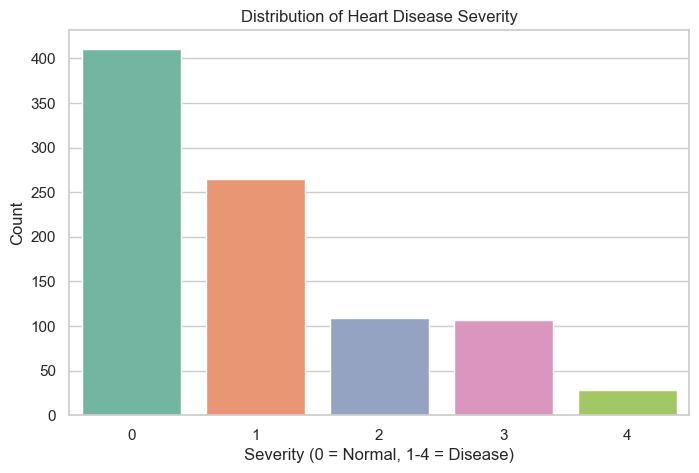

In [17]:
#  Plotting target distribution 
import matplotlib.pyplot as plt
import seaborn as sns

# Check if 'num' or 'target' is the classification column
target_col = 'num' if 'num' in df.columns else 'target'

# Set up the figure
plt.figure(figsize=(8, 5))

# Plot the count distribution with modern Seaborn parameters
sns.countplot(x=target_col, data=df, hue=target_col, palette='Set2', legend=False)

# Add titles and labels
plt.title('Distribution of Heart Disease Severity')
plt.xlabel('Severity (0 = Normal, 1-4 = Disease)')
plt.ylabel('Count')

# Display the plot
plt.show()

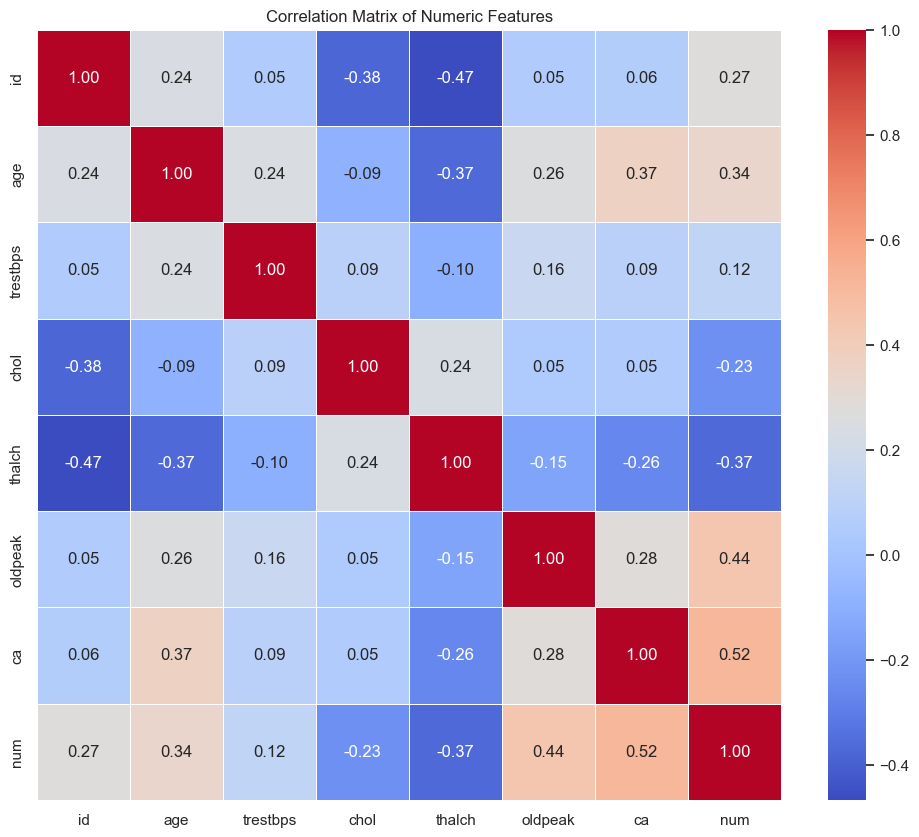

In [22]:
# Cell 5: Correlation Matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Create the figure
plt.figure(figsize=(12, 10))

# Calculate correlation on numeric columns only to avoid errors
# (The new dataset contains some text columns like 'dataset')
numeric_df = df.select_dtypes(include=['float64', 'int64'])
correlation_matrix = numeric_df.corr()

# Plot the heatmap
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)

plt.title('Correlation Matrix of Numeric Features')
plt.show()

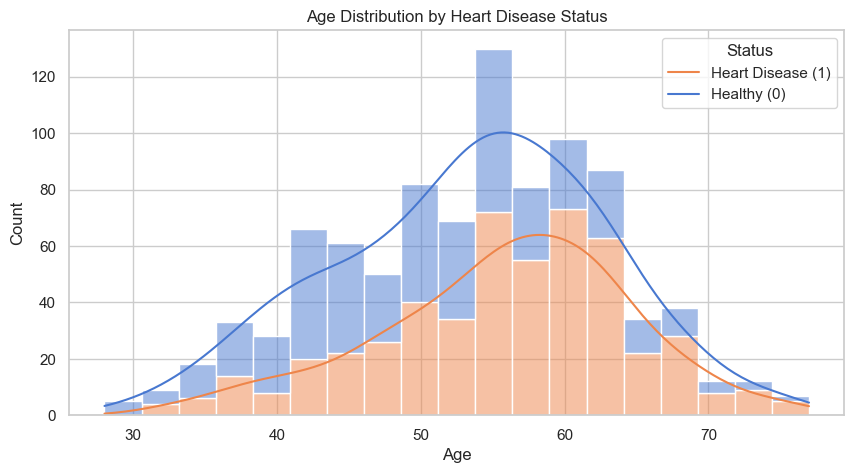

In [24]:
# Cell 6: Create target column and plot Age vs Heart Disease Distribution
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Create the binary 'target' column if it doesn't exist yet
if 'target' not in df.columns and 'num' in df.columns:
    df['target'] = (df['num'] > 0).astype(int)

# 2. Set up the figure
plt.figure(figsize=(10, 5))

# 3. Plot the histogram
sns.histplot(data=df, x='age', hue='target', multiple='stack', kde=True, palette='muted')

# Add titles and labels
plt.title('Age Distribution by Heart Disease Status')
plt.xlabel('Age')
plt.ylabel('Count')
plt.legend(title='Status', labels=['Heart Disease (1)', 'Healthy (0)'])

# Display the plot
plt.show()

In [25]:
# Cell 7: Define Features and Target
X = df.drop('target', axis=1)
y = df['target']

# Split the dataset into 80% training and 20% testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set size: {X_train.shape}")
print(f"Testing set size: {X_test.shape}")

Training set size: (736, 16)
Testing set size: (184, 16)


In [28]:
#Comprehensive Preprocessing (Silenced Warning Version)
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Drop unnecessary columns (like 'id' and 'dataset' if they exist, and 'num' since we use 'target')
cols_to_drop = [col for col in ['id', 'dataset', 'num'] if col in df.columns]
df_cleaned = df.drop(columns=cols_to_drop)

# 2. Separate Features (X) and Target (y)
X = df_cleaned.drop(columns=['target'])
y = df_cleaned['target']

# 3. Handle Missing Values (Imputation)
# Fill numeric missing values with their median
numeric_cols = X.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    X[col] = X[col].fillna(X[col].median())

# Fill categorical missing values with their mode
categorical_cols = X.select_dtypes(exclude=[np.number]).columns
for col in categorical_cols:
    X[col] = X[col].fillna(X[col].mode()[0])

# 4. One-Hot Encode Categorical Columns
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

# Convert any boolean columns (True/False) created by get_dummies to float (1.0/0.0)
X_encoded = X_encoded.astype(float)

# 5. Split into Train and Test Sets
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

# 6. Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data Preprocessing Complete (Warning Silenced)!")
print(f"Encoded features shape: {X_encoded.shape}")
print(f"Training features shape: {X_train_scaled.shape}")

Data Preprocessing Complete (Warning Silenced)!
Encoded features shape: (920, 18)
Training features shape: (736, 18)


In [30]:
# Training the Model
model = LogisticRegression(random_state=42, max_iter=1000)
model.fit(X_train_scaled, y_train)

# Make predictions
y_pred = model.predict(X_test_scaled)
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

In [31]:
# Print the first 10 predicted classes (0 = Healthy, 1 = Heart Disease)
print("First 10 predictions:", y_pred[:10])

# Print the first 10 probability scores (likelihood of heart disease)
print("First 10 probability scores:", y_pred_proba[:10].round(4))

First 10 predictions: [0 1 1 1 0 1 1 1 0 0]
First 10 probability scores: [0.4503 0.9489 0.8643 0.9281 0.3939 0.6184 0.6628 0.9467 0.1476 0.3908]


In [32]:
# Cell 10: Accuracy and Classification Report
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy on Test Set: {accuracy:.4f}\n")
print("Classification Report:")
print(classification_report(y_test, y_pred))

Model Accuracy on Test Set: 0.8424

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.79      0.82        82
           1       0.84      0.88      0.86       102

    accuracy                           0.84       184
   macro avg       0.84      0.84      0.84       184
weighted avg       0.84      0.84      0.84       184



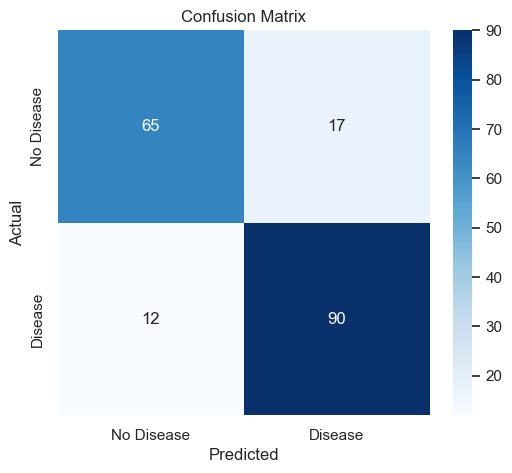

In [33]:
# Cell 11: Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No Disease', 'Disease'], 
            yticklabels=['No Disease', 'Disease'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.show()

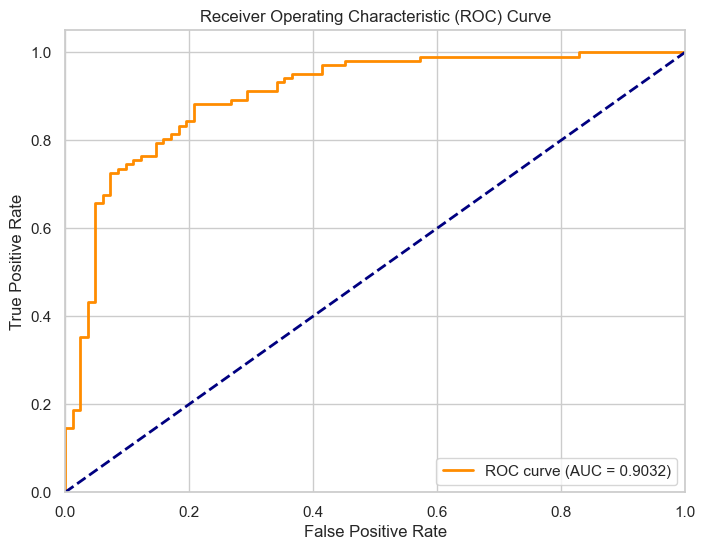

In [34]:
# Cell 12: ROC Curve and AUC Score
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = roc_auc_score(y_test, y_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

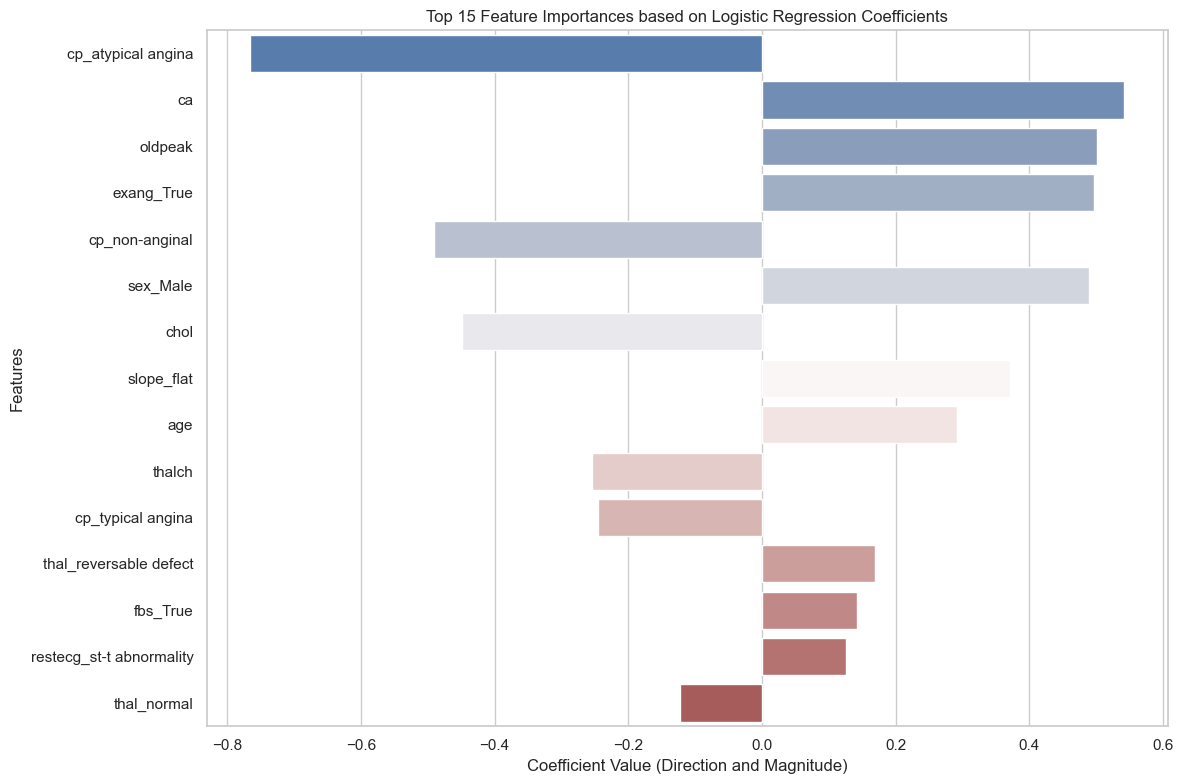

Feature Ranking:
                 Feature  Coefficient
      cp_atypical angina    -0.765309
                      ca     0.541772
                 oldpeak     0.500533
              exang_True     0.495932
          cp_non-anginal    -0.490656
                sex_Male     0.489238
                    chol    -0.448481
              slope_flat     0.371497
                     age     0.291553
                  thalch    -0.254967
       cp_typical angina    -0.245952
  thal_reversable defect     0.168825
                fbs_True     0.142201
restecg_st-t abnormality     0.125863
             thal_normal    -0.122688
                trestbps     0.068232
          restecg_normal    -0.022488
         slope_upsloping    -0.009217


In [36]:
# Cell 13: Plot Feature Importances (Corrected for Encoded Columns)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Get the coefficients from the trained model
importance = model.coef_[0]

# Create the DataFrame using X_train.columns instead of X.columns
feature_importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': importance,
    'Abs_Coefficient': np.abs(importance)
}).sort_values(by='Abs_Coefficient', ascending=False)

# Plot the features
plt.figure(figsize=(12, 8))
sns.barplot(
    x='Coefficient', 
    y='Feature', 
    data=feature_importance_df.head(15), # Plotting the top 15 most important features
    hue='Feature',
    palette='vlag',
    legend=False
)

plt.title('Top 15 Feature Importances based on Logistic Regression Coefficients')
plt.xlabel('Coefficient Value (Direction and Magnitude)')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

# Print the sorted rankings
print("Feature Ranking:")
print(feature_importance_df[['Feature', 'Coefficient']].to_string(index=False))